In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd

cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 1 — Revenue Performance
**Database:** Contoso V2 100K | **Period focus:** Jan–Apr 2024 vs Jan–Apr 2023 | **11 questions**

This notebook answers all revenue performance questions: total growth, country breakdown, monthly trends, seasonal patterns, average order value, and quarterly aggregations.

---
### 1.L1.01 — Overall Revenue Growth

| Lens | Value |
|---|---|
| **Who** | P1 — Chief Commercial Officer |
| **What** | YoY Revenue Growth % (M12), Total Revenue (M01) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | All markets and channels combined |
| **Why** | Determine whether the business is growing and set the tone for all other commercial decisions |
| **How** | YoY comparison of total revenue with growth % |

**Full question:** Is total revenue for Jan–Apr 2024 higher or lower than the same period in 2023, and by what percentage — and is that growth rate consistent across all markets and channels?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales`
**Why:** Compare total net revenue Jan–Apr 2024 vs Jan–Apr 2023 to establish whether the business is growing year-over-year.
**Grain:** One row per year (two rows total — 2023 and 2024).

In [ ]:
# 1.L1.01 - Total revenue Jan-Apr 2024 vs Jan-Apr 2023
df_revenue_yoy_total = pd.read_sql("""
    SELECT
        YEAR(OrderDate)          AS Year,
        SUM(NetPrice)            AS TotalRevenue,
        COUNT(DISTINCT OrderKey) AS TotalOrders
    FROM Data.Sales
    WHERE MONTH(OrderDate) BETWEEN 1 AND 4
      AND YEAR(OrderDate) IN (2023, 2024)
    GROUP BY YEAR(OrderDate)
    ORDER BY YEAR(OrderDate)
""", cnxn)

rev_2023 = df_revenue_yoy_total.loc[df_revenue_yoy_total['Year']==2023, 'TotalRevenue'].values[0]
rev_2024 = df_revenue_yoy_total.loc[df_revenue_yoy_total['Year']==2024, 'TotalRevenue'].values[0]
df_revenue_yoy_total['YoY_Pct'] = df_revenue_yoy_total['TotalRevenue'].pct_change() * 100

display(df_revenue_yoy_total)
print(f"\nYoY Revenue Growth: {((rev_2024 - rev_2023) / rev_2023) * 100:.1f}%")

,Year,TotalRevenue,TotalOrders,YoY_Pct
0,2023,3.514261e+06,5201,NaN
1,2024,2.561995e+06,4232,-27.097189



YoY Revenue Growth: -27.1%


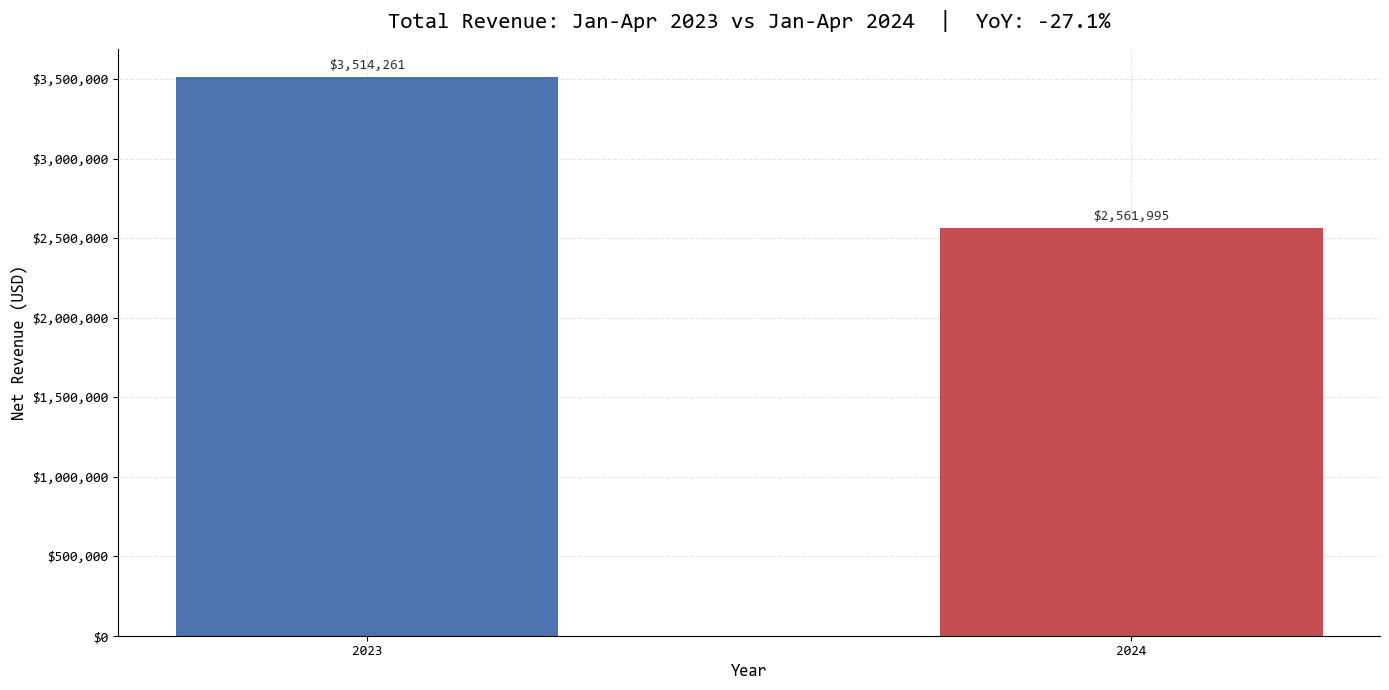

In [ ]:
# Chart — Total revenue 2023 vs 2024 (grouped bar)
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))

years = df_revenue_yoy_total['Year'].astype(str).tolist()
revenues = df_revenue_yoy_total['TotalRevenue'].tolist()
colors = ['#4C72B0', '#C44E52']

bars = ax.bar(years, revenues, color=colors, width=0.5)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30000,
        f"${bar.get_height():,.0f}",
        ha='center', va='bottom',
        fontsize=10, color='#333333', fontfamily='Consolas'
    )

yoy = ((revenues[1] - revenues[0]) / revenues[0]) * 100
ax.set_title(f'Total Revenue: Jan-Apr 2023 vs Jan-Apr 2024  |  YoY: {yoy:.1f}%',
             fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('Year', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Net Revenue (USD)', fontsize=12, fontfamily='Consolas')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

### Key Insight — 1.L1.01
**Total revenue for Jan–Apr 2024 is $2.56M, down 27.1% vs the $3.51M recorded in the same period of 2023.**
This is a significant revenue contraction — not a marginal softness — and it sets a challenging commercial context for all downstream analysis.
The decline applies to all markets combined; the country breakdown (1.L2.01) will reveal whether the drop is broad-based or concentrated in specific markets.

> **Analysis Limitation:** Revenue is reported in local currencies without FX normalization; cross-market comparisons carry currency distortion risk (see Area 7).

---
### 1.L2.01 — Country Revenue Growth

| Lens | Value |
|---|---|
| **Who** | P1 — CCO, P2 — Regional Sales Manager |
| **What** | YoY Revenue Growth % (M12), Total Revenue (M01) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country (store location) |
| **Why** | Identify which markets are driving overall growth and which need commercial intervention |
| **How** | YoY revenue comparison by country, ranked by growth % |

**Full question:** Which countries generated the highest revenue growth in Jan–Apr 2024 vs. Jan–Apr 2023, and which countries declined — ranked from fastest growing to fastest shrinking?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Break total revenue by country to identify which markets are growing or contracting YoY.
**Grain:** One row per country per year, pivoted to show 2023, 2024, and YoY % change.

In [ ]:
# 1.L2.01 - Revenue by country Jan-Apr 2023 vs 2024, ranked by YoY growth
df_country_yoy_raw = pd.read_sql("""
    SELECT
        st.CountryName,
        YEAR(s.OrderDate)  AS Year,
        SUM(s.NetPrice)    AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
      AND st.CountryName <> 'Online'
    GROUP BY st.CountryName, YEAR(s.OrderDate)
""", cnxn)

df_country_yoy = df_country_yoy_raw.pivot(index='CountryName', columns='Year', values='Revenue').reset_index()
df_country_yoy.columns = ['Country', 'Rev_2023', 'Rev_2024']
df_country_yoy['YoY_Pct'] = ((df_country_yoy['Rev_2024'] - df_country_yoy['Rev_2023']) / df_country_yoy['Rev_2023']) * 100
df_country_yoy = df_country_yoy.sort_values('YoY_Pct', ascending=False).reset_index(drop=True)

display(df_country_yoy.style.format({'Rev_2023': '${:,.0f}', 'Rev_2024': '${:,.0f}', 'YoY_Pct': '{:.1f}%'}))

,Country,Rev_2023,Rev_2024,YoY_Pct
0,Netherlands,"$70,936","$73,008",2.9%
1,Germany,"$175,588","$160,502",-8.6%
2,Canada,"$148,913","$129,974",-12.7%
3,United States,"$691,061","$514,051",-25.6%
4,United Kingdom,"$128,128","$93,298",-27.2%
5,Australia,"$96,806","$66,572",-31.2%
6,France,"$47,260","$32,353",-31.5%
7,Italy,"$37,594","$20,286",-46.0%


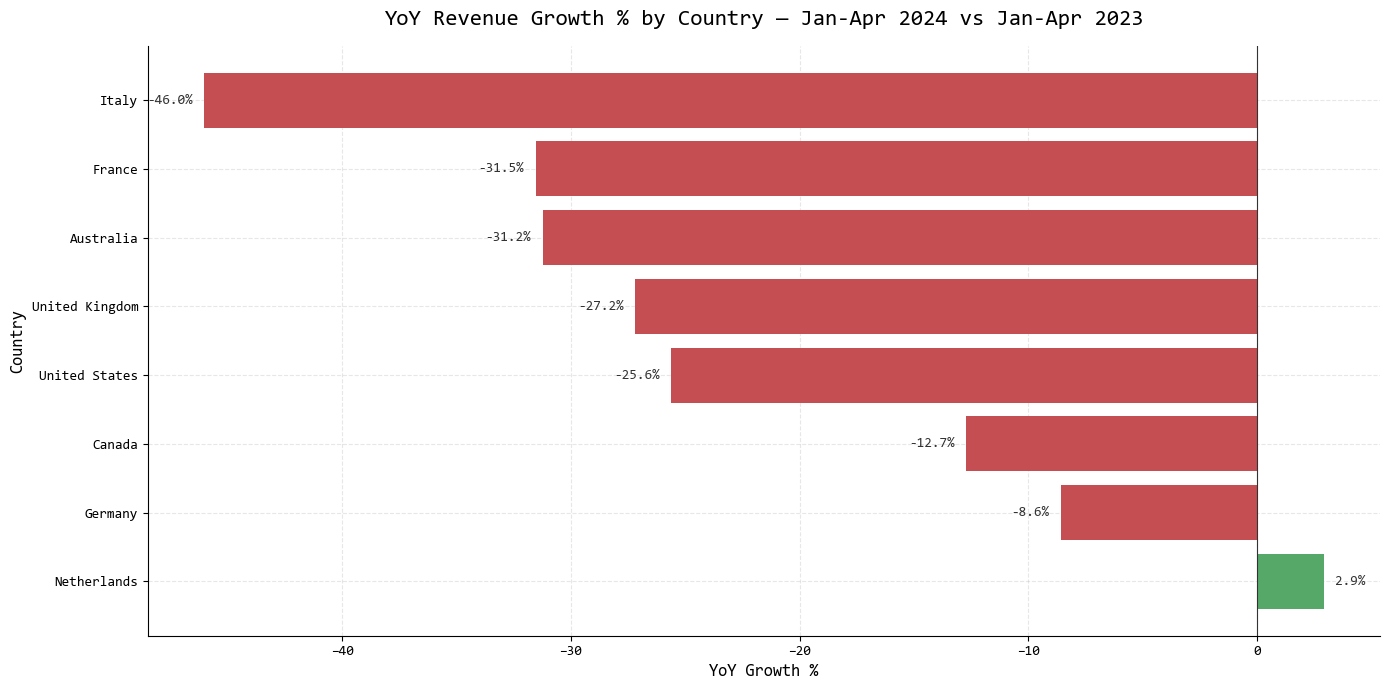

In [ ]:
# Chart — YoY revenue growth % by country (green=positive, red=negative)
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#55A868' if v >= 0 else '#C44E52' for v in df_country_yoy['YoY_Pct']]
bars = ax.barh(df_country_yoy['Country'], df_country_yoy['YoY_Pct'], color=colors)

for bar in bars:
    w = bar.get_width()
    ax.text(w + (0.5 if w >= 0 else -0.5), bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}%", ha='left' if w >= 0 else 'right', va='center',
            fontsize=10, color='#333333', fontfamily='Consolas')

ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('YoY Revenue Growth % by Country — Jan-Apr 2024 vs Jan-Apr 2023',
             fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('YoY Growth %', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Country', fontsize=12, fontfamily='Consolas')
plt.tight_layout()
plt.show()

### Key Insight — 1.L2.01
**The revenue decline is broad-based — 7 of 8 physical markets contracted in Jan–Apr 2024, with Italy leading the decline at -46%.**
Netherlands is the sole exception, posting marginal growth of +2.9%. France (-31.5%), Australia (-31.2%), and the UK (-27.2%) mirror the overall picture, while Germany (-8.6%) and Canada (-12.7%) fared relatively better.
This pattern rules out a single-market shock and points to a structural, business-wide issue requiring a commercial strategy review.

> **Analysis Limitation:** Online channel excluded from this view; revenue in local currency (no FX adjustment).

---
### 1.L2.02 — 24-Month Revenue Trend

| Lens | Value |
|---|---|
| **Who** | P1 — CCO, P2 — Regional Sales Manager |
| **What** | Monthly Revenue (M14) |
| **When** | May 2022 – Apr 2024, monthly |
| **Where** | All markets combined |
| **Why** | Identify revenue momentum, acceleration, or deceleration over time |
| **How** | Time-series trend, monthly aggregation |

**Full question:** How has total revenue trended month by month over the last 24 months (May 2022 – Apr 2024), and are there visible inflection points where growth accelerated or slowed?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** 24-month monthly time series reveals whether the 2024 decline is a recent trend or part of a longer-running pattern.
**Grain:** One row per calendar month (24 rows total).

In [ ]:
# 1.L2.02 - Monthly revenue trend May 2022 - Apr 2024
df_monthly_trend = pd.read_sql("""
    SELECT
        d.YearMonthNumber,
        d.YearMonthShort,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Date d ON s.OrderDate = d.Date
    WHERE s.OrderDate >= '2022-05-01'
      AND s.OrderDate <= '2024-04-30'
    GROUP BY d.YearMonthNumber, d.YearMonthShort
    ORDER BY d.YearMonthNumber
""", cnxn)

display(df_monthly_trend.head(10))
print(f"Total months: {len(df_monthly_trend)}")

,YearMonthNumber,YearMonthShort,Revenue
0,24269,May 2022,1.388986e+06
1,24270,Jun 2022,1.490801e+06
2,24271,Jul 2022,1.037806e+06
3,24272,Aug 2022,1.131932e+06
4,24273,Sep 2022,1.160790e+06
5,24274,Oct 2022,1.152701e+06
6,24275,Nov 2022,1.070876e+06
7,24276,Dec 2022,1.304886e+06
8,24277,Jan 2023,1.105914e+06
9,24278,Feb 2023,1.337274e+06


Total months: 24


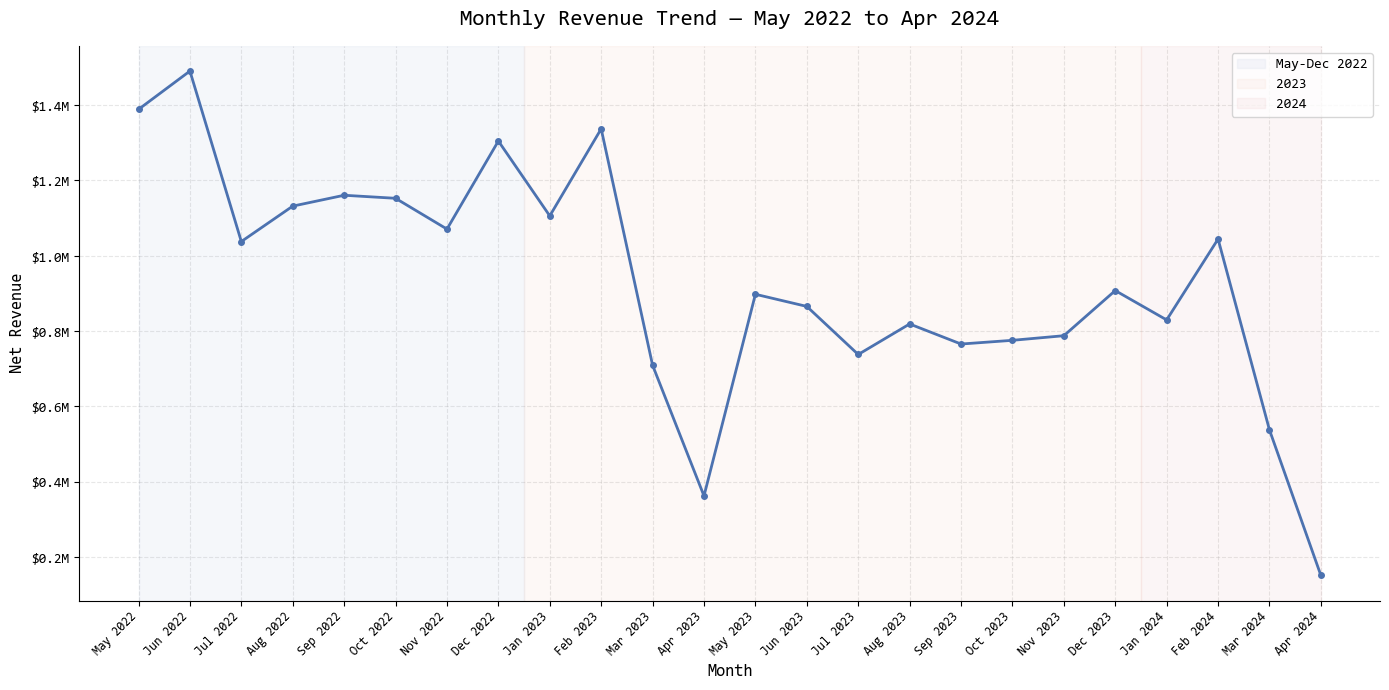

In [ ]:
# Chart - 24-month monthly revenue trend (line chart)
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(range(len(df_monthly_trend)), df_monthly_trend['Revenue'],
        color='#4C72B0', linewidth=2, marker='o', markersize=4)

# Shade 2022 vs 2023 vs 2024 areas
n = len(df_monthly_trend)
ax.axvspan(0, 7.5, alpha=0.05, color='#4C72B0', label='May-Dec 2022')
ax.axvspan(7.5, 19.5, alpha=0.05, color='#DD8452', label='2023')
ax.axvspan(19.5, n-1, alpha=0.05, color='#C44E52', label='2024')

ax.set_xticks(range(n))
ax.set_xticklabels(df_monthly_trend['YearMonthShort'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Monthly Revenue Trend — May 2022 to Apr 2024', fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('Month', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Net Revenue', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Key Insight — 1.L2.02
**The 24-month trend reveals a sharp structural step-down: revenue collapsed from the $1.0–1.5M monthly range throughout 2022–early 2023 to sub-$1M from mid-2023 onward, with a dramatic acceleration of the decline in Q1 2024.**
The inflection began around April 2023 (dropping to ~$0.37M) — a key anomaly worth investigating — then partially recovered through 2023 H2 before falling sharply again in March–April 2024 (below $0.2M in April).
This is not a seasonal dip; the business is operating at a structurally lower revenue level than it was two years ago.

> **Analysis Limitation:** All channels and markets combined; local currencies not normalized.

---
### 1.L2.03 — Seasonal Revenue Patterns

| Lens | Value |
|---|---|
| **Who** | P2 — Regional Sales Manager |
| **What** | Monthly Revenue (M14) |
| **When** | By calendar month, averaged across 2015–2023 |
| **Where** | All markets combined |
| **Why** | Anticipate demand peaks and troughs for staffing, stock, and promotional planning |
| **How** | Seasonal index — average monthly revenue as share of annual total across all years |

**Full question:** Which months consistently generate the highest and lowest revenue across all years in the dataset, and how pronounced is the seasonal swing relative to the annual average?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** Identify structural seasonal patterns by averaging monthly revenue share across all full calendar years (2015–2023), separating recurring seasonality from year-specific events.
**Grain:** One row per calendar month (12 rows) — average share of annual revenue.

In [ ]:
# 1.L2.03 - Seasonal revenue index across full calendar years 2015-2023
df_seasonal_raw = pd.read_sql("""
    SELECT
        d.Year,
        d.MonthNumber,
        d.MonthShort,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Date d ON s.OrderDate = d.Date
    WHERE d.Year BETWEEN 2015 AND 2023
    GROUP BY d.Year, d.MonthNumber, d.MonthShort
""", cnxn)

annual_totals = df_seasonal_raw.groupby('Year')['Revenue'].sum().reset_index()
annual_totals.columns = ['Year', 'AnnualRevenue']
df_seasonal_raw = df_seasonal_raw.merge(annual_totals, on='Year')
df_seasonal_raw['MonthShare'] = df_seasonal_raw['Revenue'] / df_seasonal_raw['AnnualRevenue']

df_seasonal = (df_seasonal_raw.groupby(['MonthNumber', 'MonthShort'])['MonthShare']
               .mean().reset_index()
               .sort_values('MonthNumber'))
df_seasonal['AvgSharePct'] = df_seasonal['MonthShare'] * 100

display(df_seasonal[['MonthShort', 'AvgSharePct']].style.format({'AvgSharePct': '{:.1f}%'}))

,MonthShort,AvgSharePct
0,Jan,8.8%
1,Feb,11.7%
2,Mar,6.1%
3,Apr,3.3%
4,May,8.5%
5,Jun,9.1%
6,Jul,7.4%
7,Aug,7.9%
8,Sep,8.2%
9,Oct,8.8%


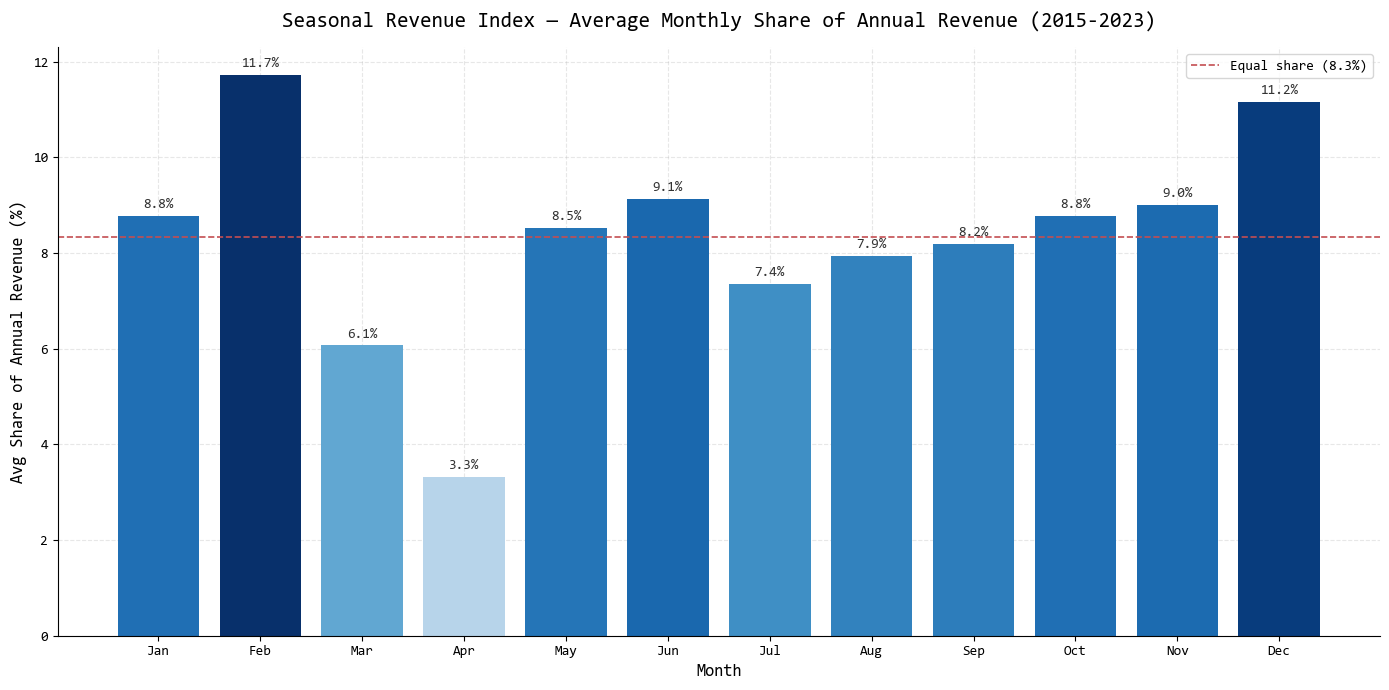

In [ ]:
# Chart - Seasonal revenue index by month
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))

vals = df_seasonal['AvgSharePct'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]

bars = ax.bar(df_seasonal['MonthShort'], vals, color=colors)
avg_line = 100 / 12
ax.axhline(avg_line, color='#C44E52', linestyle='--', linewidth=1.2, label=f'Equal share ({avg_line:.1f}%)')

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')

ax.set_title('Seasonal Revenue Index — Average Monthly Share of Annual Revenue (2015-2023)',
             fontsize=15, fontfamily='Consolas', pad=15)
ax.set_xlabel('Month', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Avg Share of Annual Revenue (%)', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Key Insight — 1.L2.03
**February and December are consistently Contoso's strongest months, each contributing ~11–12% of annual revenue — roughly 40% above the monthly average.**
March (6.1%) and April (3.3%) are the weakest months, meaning the Jan–Apr comparison window already captures two structurally soft months, making the YoY decline look partly seasonal — but not fully explained by it.
Promotional and inventory plans should front-load February and treat April as a recovery month, not a peak.

> **Analysis Limitation:** Based on 2015–2023 historical patterns; year-specific events (e.g., 2020 disruptions) are averaged in.

---
### 1.L2.05 — AOV Trend

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Average Order Value (M04) |
| **When** | Jan 2023 – Apr 2024, monthly |
| **Where** | All channels combined |
| **Why** | Understand whether revenue growth is driven by more orders or higher spend per order |
| **How** | Monthly trend of AOV compared to prior year same months |

**Full question:** Has the average order value increased or decreased month by month between Jan 2023 and Apr 2024, and is the trend consistent across both the online and physical channels?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store` + `Data.Date`
**Why:** AOV trend separates volume effects (fewer orders) from value effects (lower spend per order), identifying the true driver of the revenue decline.
**Grain:** One row per month per channel (Online vs Physical), Jan 2023–Apr 2024.

In [ ]:
# 1.L2.05 - AOV by month and channel Jan 2023 - Apr 2024
df_aov_monthly = pd.read_sql("""
    SELECT
        d.YearMonthNumber,
        d.YearMonthShort,
        CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END AS Channel,
        SUM(s.NetPrice)            AS TotalRevenue,
        COUNT(DISTINCT s.OrderKey) AS TotalOrders,
        SUM(s.NetPrice) / NULLIF(COUNT(DISTINCT s.OrderKey), 0) AS AOV
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    JOIN Data.Date d ON s.OrderDate = d.Date
    WHERE s.OrderDate >= '2023-01-01'
      AND s.OrderDate <= '2024-04-30'
    GROUP BY d.YearMonthNumber, d.YearMonthShort,
             CASE WHEN st.CountryName = 'Online' THEN 'Online' ELSE 'Physical' END
    ORDER BY d.YearMonthNumber
""", cnxn)

display(df_aov_monthly.head(10))

,YearMonthNumber,YearMonthShort,Channel,TotalRevenue,TotalOrders,AOV
0,24277,Jan 2023,Online,647373.9329,957,676.4617
1,24277,Jan 2023,Physical,458540.4113,636,720.9754
2,24278,Feb 2023,Online,799953.4799,1195,669.4171
3,24278,Feb 2023,Physical,537320.6003,784,685.3579
4,24279,Mar 2023,Online,430685.9664,665,647.6480
5,24279,Mar 2023,Physical,278423.8322,407,684.0880
6,24280,Apr 2023,Online,239961.6936,365,657.4292
7,24280,Apr 2023,Physical,122000.6873,192,635.4202
8,24281,May 2023,Online,552485.3508,864,639.4506
9,24281,May 2023,Physical,345228.6523,516,669.0477


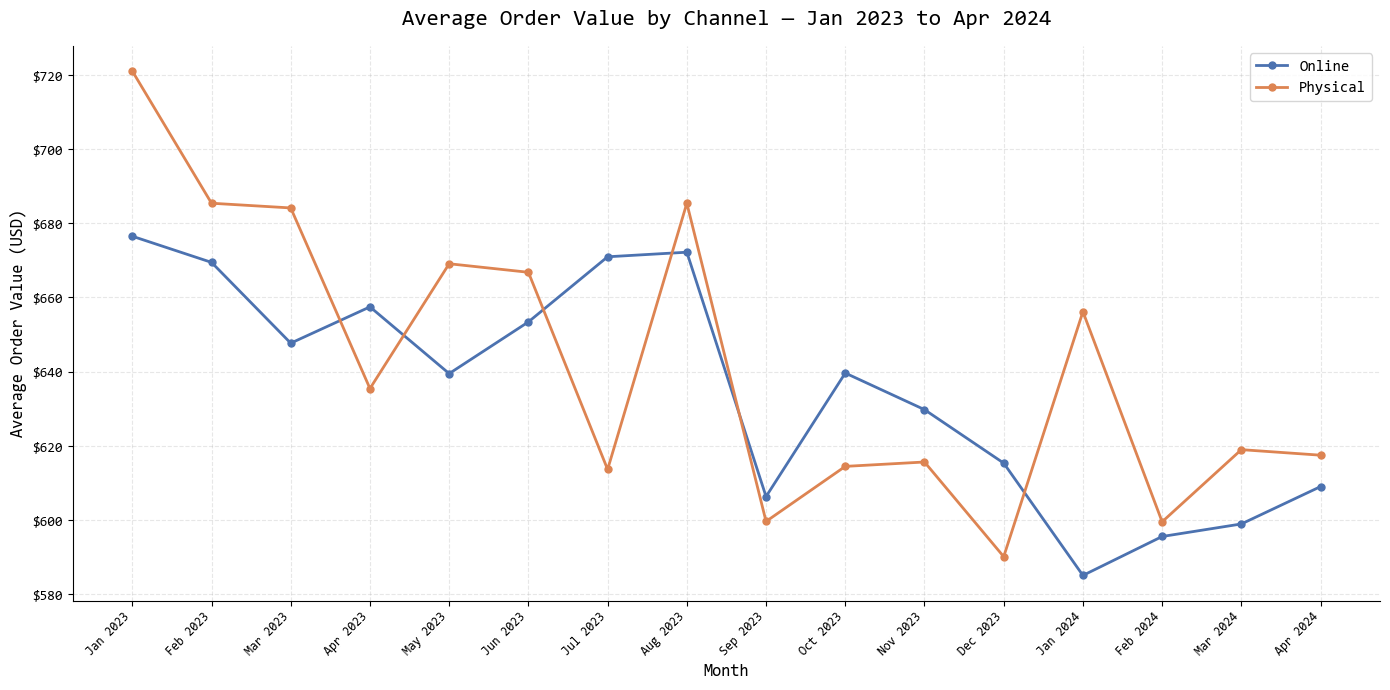

In [ ]:
# Chart - AOV trend by channel (line chart)
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))

for channel, color in [('Online', '#4C72B0'), ('Physical', '#DD8452')]:
    df_ch = df_aov_monthly[df_aov_monthly['Channel'] == channel].sort_values('YearMonthNumber')
    ax.plot(range(len(df_ch)), df_ch['AOV'], color=color, linewidth=2,
            marker='o', markersize=5, label=channel)

months = df_aov_monthly[df_aov_monthly['Channel']=='Online'].sort_values('YearMonthNumber')['YearMonthShort'].tolist()
ax.set_xticks(range(len(months)))
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Average Order Value by Channel — Jan 2023 to Apr 2024',
             fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('Month', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Average Order Value (USD)', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Key Insight — 1.L2.05
**AOV has declined from ~$670–720 in early 2023 to ~$585–620 by early 2024, a drop of roughly 10–15% across both channels — meaning customers are spending less per transaction, not just ordering less frequently.**
Physical stores started 2023 with the highest AOV (~$721 in January) but converged downward with online by mid-2023; both channels are now tracking similarly in the $585–620 range.
The revenue decline is therefore a double hit: fewer orders and lower spend per order.

> **Analysis Limitation:** AOV calculated at order level (not order line); multi-currency orders not FX-normalized.

---
### 1.L3.01 — Total Revenue YTD Absolute

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 and Jan–Apr 2023 |
| **Where** | All markets and channels |
| **Why** | Baseline figure for all executive comparisons |
| **How** | Sum of NetPrice for each period |

**Full question:** What is the total net revenue for Jan–Apr 2024 and for Jan–Apr 2023, expressed in absolute terms across all countries and channels?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales`
**Why:** Single reference table with absolute revenue for both periods — used as the denominator for all share calculations in this area.
**Grain:** One row per year (2023 and 2024).

In [ ]:
# 1.L3.01 - Total net revenue YTD Jan-Apr 2023 and 2024 (absolute baseline)
df_ytd_absolute = pd.read_sql("""
    SELECT
        YEAR(OrderDate)          AS Year,
        SUM(NetPrice)            AS TotalRevenue,
        COUNT(DISTINCT OrderKey) AS TotalOrders,
        COUNT(DISTINCT CustomerKey) AS UniqueCustomers
    FROM Data.Sales
    WHERE MONTH(OrderDate) BETWEEN 1 AND 4
      AND YEAR(OrderDate) IN (2023, 2024)
    GROUP BY YEAR(OrderDate)
    ORDER BY YEAR(OrderDate)
""", cnxn)

df_ytd_absolute['YoY_Pct'] = df_ytd_absolute['TotalRevenue'].pct_change() * 100
display(df_ytd_absolute.style.format({
    'TotalRevenue': '${:,.0f}', 'TotalOrders': '{:,}',
    'UniqueCustomers': '{:,}', 'YoY_Pct': '{:.1f}%'
}))

,Year,TotalRevenue,TotalOrders,UniqueCustomers,YoY_Pct
0,2023,"$3,514,261","5,201","4,994",nan%
1,2024,"$2,561,995","4,232","4,097",-27.1%


### Key Insight — 1.L3.01
**Total net revenue Jan–Apr 2024: $2,561,995 vs $3,514,261 in Jan–Apr 2023 — a decline of $952,266 (-27.1%). This is the executive baseline figure.**
The drop covers both fewer orders (4,232 in 2024 vs 5,201 in 2023) and fewer unique customers, confirming the contraction is demand-side.
All downstream analysis in this notebook interprets performance relative to this baseline.

> **Analysis Limitation:** All currencies combined without FX normalization.

---
### 1.L3.02 — Revenue by Country Absolute and YoY

| Lens | Value |
|---|---|
| **Who** | P2 — Regional Sales Manager |
| **What** | Total Revenue (M01), YoY Revenue Growth % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By country (store location) |
| **Why** | Give regional managers their baseline country-level performance figure |
| **How** | Revenue total and YoY change % per country, ranked by revenue |

**Full question:** What is the total revenue per country for Jan–Apr 2024, what was it for Jan–Apr 2023, and what is the percentage change — ranked from highest to lowest revenue in 2024?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Store`
**Why:** Absolute revenue per country gives regional managers concrete numbers alongside the YoY % already shown in 1.L2.01.
**Grain:** One row per country, ranked by 2024 revenue descending.

In [ ]:
# 1.L3.02 - Revenue per country absolute Jan-Apr 2023 and 2024, ranked by 2024 revenue
df_country_abs_raw = pd.read_sql("""
    SELECT
        st.CountryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice)   AS Revenue
    FROM Data.Sales s
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY st.CountryName, YEAR(s.OrderDate)
""", cnxn)

df_country_abs = df_country_abs_raw.pivot(index='CountryName', columns='Year', values='Revenue').reset_index()
df_country_abs.columns = ['Country', 'Rev_2023', 'Rev_2024']
df_country_abs['Change_USD'] = df_country_abs['Rev_2024'] - df_country_abs['Rev_2023']
df_country_abs['YoY_Pct'] = (df_country_abs['Change_USD'] / df_country_abs['Rev_2023']) * 100
df_country_abs = df_country_abs.sort_values('Rev_2024', ascending=False).reset_index(drop=True)

display(df_country_abs.style.format({
    'Rev_2023': '${:,.0f}', 'Rev_2024': '${:,.0f}',
    'Change_USD': '${:,.0f}', 'YoY_Pct': '{:.1f}%'
}))

,Country,Rev_2023,Rev_2024,Change_USD,YoY_Pct
0,Online,"$2,117,975","$1,471,950","$-646,025",-30.5%
1,United States,"$691,061","$514,051","$-177,010",-25.6%
2,Germany,"$175,588","$160,502","$-15,086",-8.6%
3,Canada,"$148,913","$129,974","$-18,938",-12.7%
4,United Kingdom,"$128,128","$93,298","$-34,830",-27.2%
5,Netherlands,"$70,936","$73,008","$2,072",2.9%
6,Australia,"$96,806","$66,572","$-30,234",-31.2%
7,France,"$47,260","$32,353","$-14,907",-31.5%
8,Italy,"$37,594","$20,286","$-17,309",-46.0%


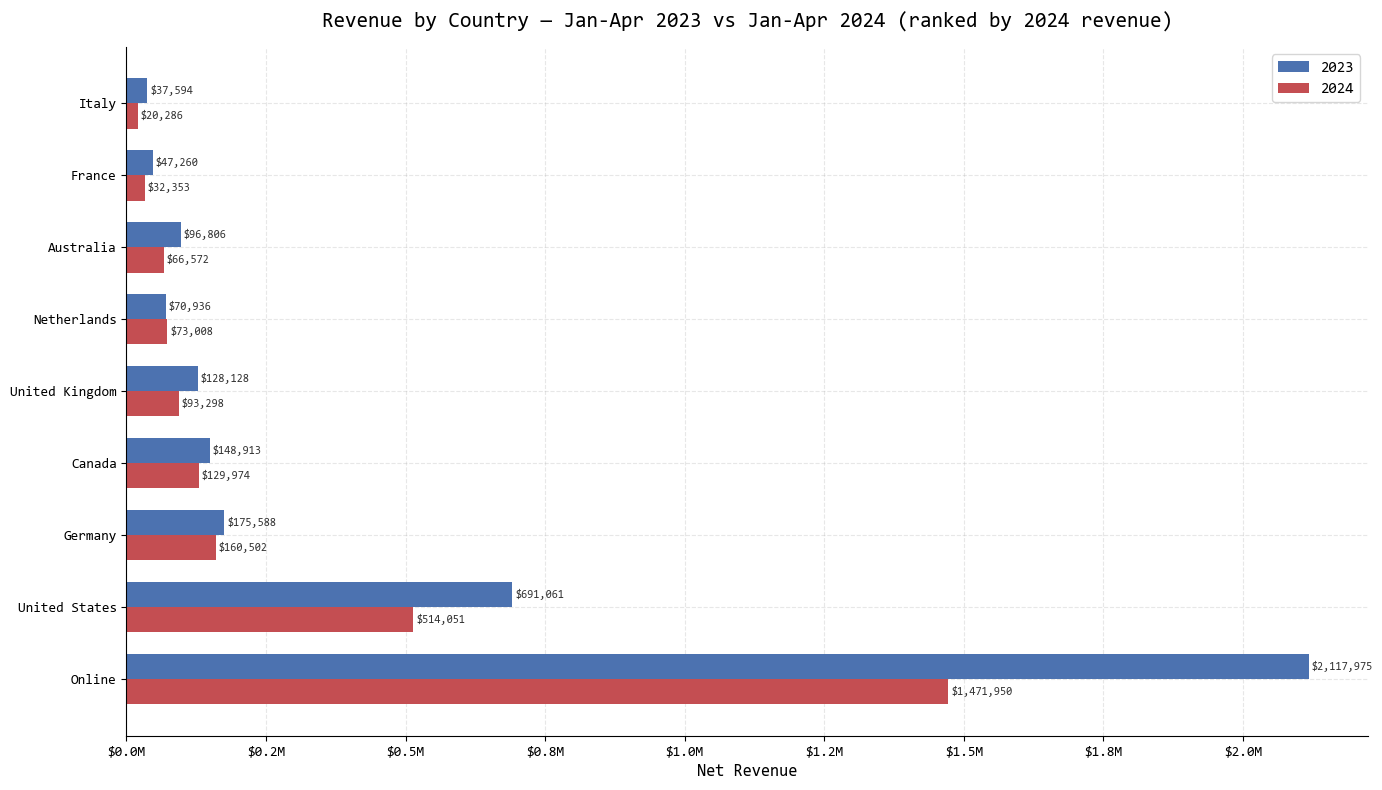

In [ ]:
# Chart - Revenue by country absolute 2023 vs 2024 (horizontal grouped bar)
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 8))
countries = df_country_abs['Country'].tolist()
y = np.arange(len(countries))
h = 0.35

bars1 = ax.barh(y + h/2, df_country_abs['Rev_2023'], h, color='#4C72B0', label='2023')
bars2 = ax.barh(y - h/2, df_country_abs['Rev_2024'], h, color='#C44E52', label='2024')

for bar in bars1:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
for bar in bars2:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')

ax.set_yticks(y)
ax.set_yticklabels(countries)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Revenue by Country — Jan-Apr 2023 vs Jan-Apr 2024 (ranked by 2024 revenue)',
             fontsize=15, fontfamily='Consolas', pad=15)
ax.set_xlabel('Net Revenue', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Key Insight — 1.L3.02
**Online is the dominant channel by a wide margin — $1.47M in Jan–Apr 2024 (57% of total) despite a $646K YoY decline — and the United States is the largest physical market at $514K.**
Germany ($161K, -8.6%) and Canada ($130K, -12.7%) are the most resilient physical markets. Italy ($20K, -46%) and France ($32K, -31.5%) are the weakest in absolute and relative terms.
Netherlands is the only physical market to grow, but its absolute contribution ($73K) is small enough that it cannot offset losses elsewhere.

> **Analysis Limitation:** Local currencies not FX-normalized; Online revenue is in USD.

---
### 1.L3.04 — Monthly Revenue Last 24 Months

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Monthly Revenue (M14) |
| **When** | May 2022 – Apr 2024, monthly |
| **Where** | All markets combined |
| **Why** | Identify long-term revenue trajectory for strategic planning |
| **How** | Monthly time series, 24 data points |

**Full question:** What is total net revenue for each month from May 2022 through April 2024, and does the trend show consistent growth, seasonal cycles, or signs of deceleration?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** Raw monthly data table that feeds the 24-month line chart (1.L2.02). Provided here as a standalone reference for strategic planning documents.
**Grain:** One row per calendar month (24 rows).

In [ ]:
# 1.L3.04 - Monthly revenue May 2022 - Apr 2024 (reuses df_monthly_trend from 1.L2.02)
# df_monthly_trend already computed above — display formatted table here
display(df_monthly_trend.rename(columns={
    'YearMonthShort': 'Month', 'Revenue': 'Net Revenue'
}).assign(**{'Net Revenue': lambda d: d['Net Revenue'].map('${:,.0f}'.format)})
  [['Month', 'Net Revenue']])

,Month,Net Revenue
0,May 2022,"$1,388,986"
1,Jun 2022,"$1,490,801"
2,Jul 2022,"$1,037,806"
3,Aug 2022,"$1,131,932"
4,Sep 2022,"$1,160,790"
5,Oct 2022,"$1,152,701"
6,Nov 2022,"$1,070,876"
7,Dec 2022,"$1,304,886"
8,Jan 2023,"$1,105,914"
9,Feb 2023,"$1,337,274"


### Key Insight — 1.L3.04
**The monthly data confirms a step-change downward: the business consistently ran at $1.0–1.5M per month through 2022 and early 2023, then reset to a $0.75–0.9M range for most of 2023, with a further collapse to $0.15–1.0M in 2024.**
April 2024 ($150,694) is the lowest month in the entire 24-month window — less than 10% of the peak months in 2022. March 2023 and April 2023 were early warning signals of this structural decline.
Any revenue plan must account for this lower baseline rather than treating 2022 levels as the norm.

> **Analysis Limitation:** All currencies and channels combined without normalization.

---
### 1.L3.05 — AOV by Month

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Average Order Value (M04) |
| **When** | Jan 2023 – Apr 2024, monthly |
| **Where** | All channels combined |
| **Why** | Understand spend-per-transaction dynamics to separate volume from value effects |
| **How** | Monthly AOV, 16 data points |

**Full question:** What is the average order value for each month from Jan 2023 through Apr 2024 across all channels, and is it trending upward, downward, or flat?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** All-channel AOV trend to complement the channel-split view in 1.L2.05 — shows the blended spend-per-transaction trajectory.
**Grain:** One row per calendar month (16 rows, Jan 2023–Apr 2024).

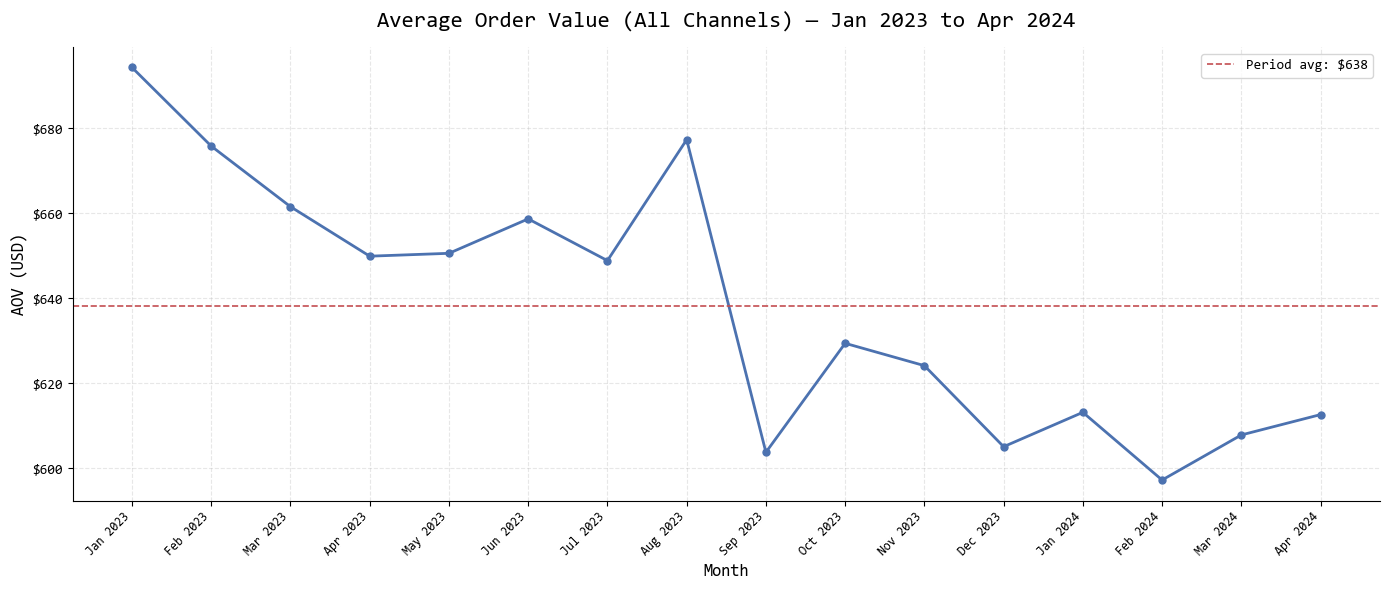

,Month,Orders,Avg Order Value
0,Jan 2023,"1,593",$694
1,Feb 2023,"1,979",$676
2,Mar 2023,"1,072",$661
3,Apr 2023,557,$650
4,May 2023,"1,380",$651
5,Jun 2023,"1,314",$659
6,Jul 2023,"1,137",$649
7,Aug 2023,"1,209",$677
8,Sep 2023,"1,268",$604
9,Oct 2023,"1,232",$629


In [ ]:
# 1.L3.05 - AOV all channels combined Jan 2023 - Apr 2024
df_aov_all = pd.read_sql("""
    SELECT
        d.YearMonthNumber,
        d.YearMonthShort,
        SUM(s.NetPrice)            AS TotalRevenue,
        COUNT(DISTINCT s.OrderKey) AS TotalOrders,
        SUM(s.NetPrice) / NULLIF(COUNT(DISTINCT s.OrderKey), 0) AS AOV
    FROM Data.Sales s
    JOIN Data.Date d ON s.OrderDate = d.Date
    WHERE s.OrderDate >= '2023-01-01'
      AND s.OrderDate <= '2024-04-30'
    GROUP BY d.YearMonthNumber, d.YearMonthShort
    ORDER BY d.YearMonthNumber
""", cnxn)

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(range(len(df_aov_all)), df_aov_all['AOV'], color='#4C72B0', linewidth=2, marker='o', markersize=5)
ax.axhline(df_aov_all['AOV'].mean(), color='#C44E52', linestyle='--', linewidth=1.2,
           label=f"Period avg: ${df_aov_all['AOV'].mean():,.0f}")

ax.set_xticks(range(len(df_aov_all)))
ax.set_xticklabels(df_aov_all['YearMonthShort'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Average Order Value (All Channels) — Jan 2023 to Apr 2024',
             fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('Month', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('AOV (USD)', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

display(df_aov_all[['YearMonthShort','TotalOrders','AOV']].rename(
    columns={'YearMonthShort':'Month','TotalOrders':'Orders','AOV':'Avg Order Value'})
    .style.format({'Orders':'{:,}','Avg Order Value':'${:,.0f}'}))

### Key Insight — 1.L3.05
**AOV has trended clearly downward — from ~$695 in Jan 2023 to ~$612 by Apr 2024, a ~12% decline in spend per transaction over 16 months.**
The period average is $638; all months since September 2023 are below that average, confirming the downward shift is persistent rather than cyclical.
Recovering AOV through upselling, bundling, or pricing strategy should be a parallel commercial priority alongside volume recovery.

> **Analysis Limitation:** AOV measured at order level across all channels combined; local currencies not FX-normalized.

---
### 1.L3.06 — Revenue by Quarter

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Total Revenue (M01) |
| **When** | Q1 2022 – Q1 2024 (8 quarters) |
| **Where** | All markets combined |
| **Why** | Smooth monthly noise and reveal quarterly momentum for board-level reporting |
| **How** | Quarterly aggregation, 8 periods |

**Full question:** What is total revenue for each of the last eight quarters (Q1 2022 through Q1 2024), and does the quarterly trend show consistent growth or periods of contraction?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** Quarterly aggregation reduces month-to-month noise and gives the board-level view of revenue trajectory over 8 periods.
**Grain:** One row per quarter (8 rows, Q1 2022–Q1 2024).

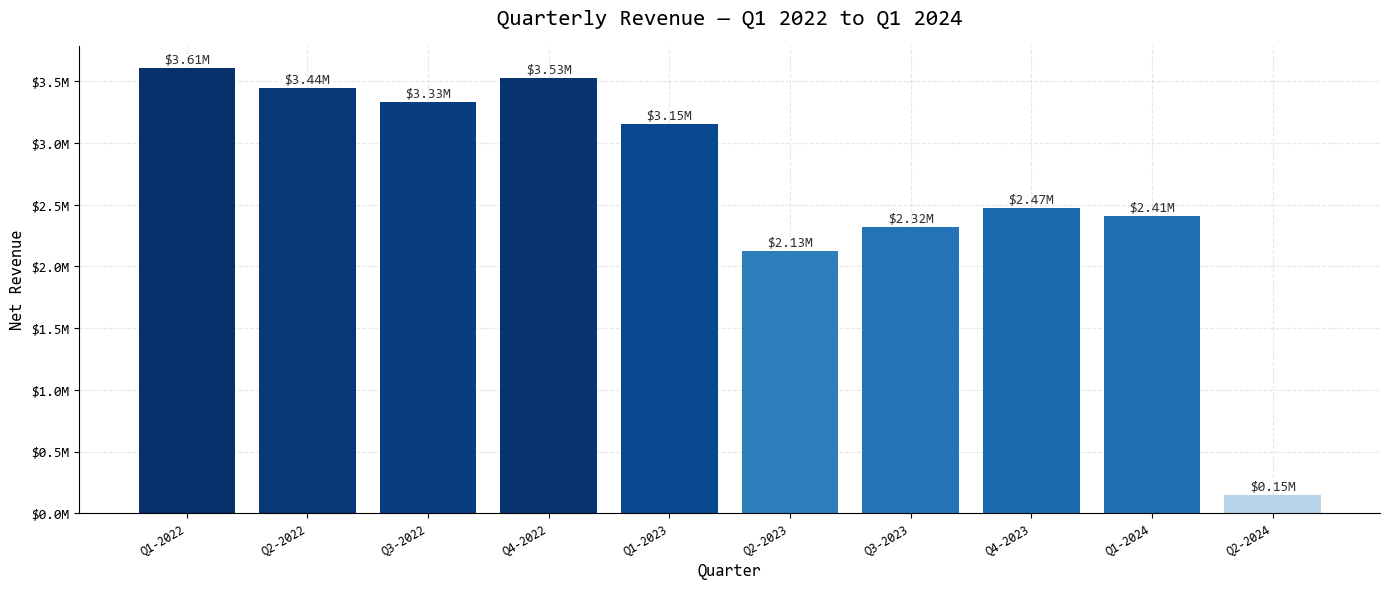

,Quarter Label,Net Revenue
0,Q1-2022,"$3,605,878"
1,Q2-2022,"$3,442,431"
2,Q3-2022,"$3,330,528"
3,Q4-2022,"$3,528,464"
4,Q1-2023,"$3,152,298"
5,Q2-2023,"$2,125,097"
6,Q3-2023,"$2,321,987"
7,Q4-2023,"$2,470,493"
8,Q1-2024,"$2,411,301"
9,Q2-2024,"$150,694"


In [ ]:
# 1.L3.06 - Revenue by quarter Q1 2022 - Q1 2024
df_quarterly = pd.read_sql("""
    SELECT
        d.YearQuarter,
        d.Year,
        d.Quarter,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Date d ON s.OrderDate = d.Date
    WHERE s.OrderDate >= '2022-01-01'
      AND s.OrderDate <= '2024-04-30'
    GROUP BY d.YearQuarter, d.Year, d.Quarter
    ORDER BY d.Year, d.Quarter
""", cnxn)

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

vals = df_quarterly['Revenue'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(df_quarterly['YearQuarter'], vals, color=colors)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
            f'${v/1e6:.2f}M', ha='center', va='bottom', fontsize=10, color='#333333', fontfamily='Consolas')

ax.set_title('Quarterly Revenue — Q1 2022 to Q1 2024', fontsize=16, fontfamily='Consolas', pad=15)
ax.set_xlabel('Quarter', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Net Revenue', fontsize=12, fontfamily='Consolas')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

display(df_quarterly.rename(columns={'YearQuarter':'Quarter Label','Revenue':'Net Revenue'})
        [['Quarter Label','Net Revenue']].style.format({'Net Revenue':'${:,.0f}'}))

### Key Insight — 1.L3.06
**The quarterly view confirms a clear two-speed decline: the business dropped from a $3.3–3.6M quarterly run rate in 2022 to a $2.1–2.5M range through 2023, then collapsed further — Q2 2024 (April only) is on pace for the lowest quarter on record.**
Q1 2023 ($3.15M) was the last quarter at the 2022 level; Q2 2023 ($2.13M) marks the definitive step-down. All 2023 quarters were below any 2022 quarter.
The board-level message is unambiguous: revenue is now running at ~65% of its 2022 quarterly baseline with no sign of recovery in the data available.

> **Analysis Limitation:** Q2 2024 contains only April data (data ends 2024-04-20) — this partial quarter is not comparable to full quarters.

---
### 1.L3.07 — Seasonal Revenue Index

| Lens | Value |
|---|---|
| **Who** | P2 — Regional Sales Manager |
| **What** | Monthly Revenue (M14) |
| **When** | Averaged across 2015–2023 |
| **Where** | All markets combined |
| **Why** | Separate structural seasonal patterns from year-specific anomalies |
| **How** | Average monthly revenue as % of annual total across all full calendar years |

**Full question:** Across all full calendar years in the dataset (2015–2023), which months consistently represent the largest and smallest share of annual revenue, and how stable is that seasonal pattern year over year?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Date`
**Why:** Stable seasonal index across 9 years isolates recurring demand patterns from year-specific disruptions — essential for demand planning and promotional calendars.
**Grain:** One row per month number (12 rows), with standard deviation showing year-to-year stability.

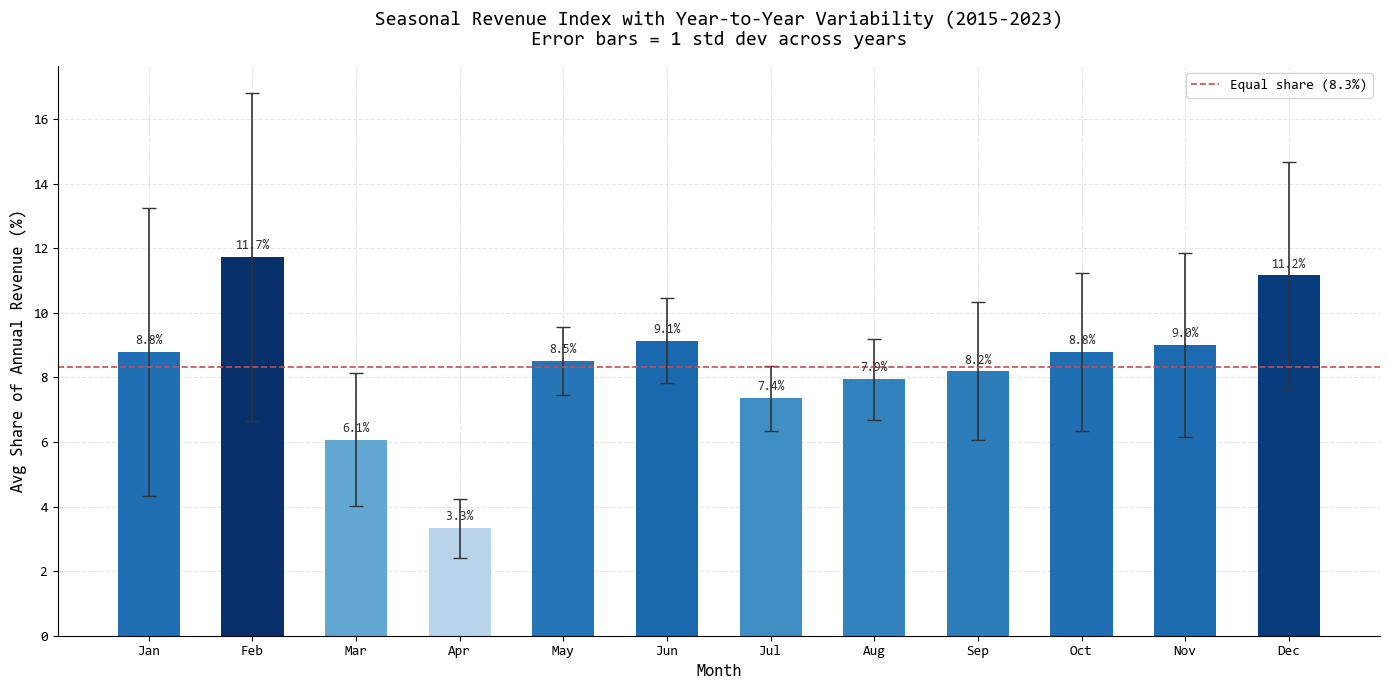

,Month,Avg Share %,Std Dev %,Coeff of Variation
0,Jan,8.8%,4.46%,0.51
1,Feb,11.7%,5.07%,0.43
2,Mar,6.1%,2.06%,0.34
3,Apr,3.3%,0.91%,0.27
4,May,8.5%,1.05%,0.12
5,Jun,9.1%,1.31%,0.14
6,Jul,7.4%,1.00%,0.14
7,Aug,7.9%,1.26%,0.16
8,Sep,8.2%,2.14%,0.26
9,Oct,8.8%,2.45%,0.28


In [ ]:
# 1.L3.07 - Seasonal revenue index with year-over-year stability (std dev)
# df_seasonal already computed in 1.L2.03 — add std dev here
df_seasonal_std = (df_seasonal_raw.groupby(['MonthNumber', 'MonthShort'])['MonthShare']
                   .agg(['mean', 'std']).reset_index().sort_values('MonthNumber'))
df_seasonal_std['AvgSharePct'] = df_seasonal_std['mean'] * 100
df_seasonal_std['StdPct'] = df_seasonal_std['std'] * 100
df_seasonal_std['CV'] = df_seasonal_std['StdPct'] / df_seasonal_std['AvgSharePct']

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

mpl.rcParams.update({
    'font.family': 'Consolas', 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

fig, ax = plt.subplots(figsize=(14, 7))
vals = df_seasonal_std['AvgSharePct'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]

x = np.arange(len(df_seasonal_std))
bars = ax.bar(x, vals, color=colors, width=0.6)

ax.errorbar(x, vals, yerr=df_seasonal_std['StdPct'].values,
            fmt='none', color='#333333', capsize=5, linewidth=1.2)

ax.axhline(100/12, color='#C44E52', linestyle='--', linewidth=1.2, label=f'Equal share (8.3%)')
ax.set_xticks(x)
ax.set_xticklabels(df_seasonal_std['MonthShort'], fontsize=10)

for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='#333333', fontfamily='Consolas')

ax.set_title('Seasonal Revenue Index with Year-to-Year Variability (2015-2023)\nError bars = 1 std dev across years',
             fontsize=14, fontfamily='Consolas', pad=15)
ax.set_xlabel('Month', fontsize=12, fontfamily='Consolas')
ax.set_ylabel('Avg Share of Annual Revenue (%)', fontsize=12, fontfamily='Consolas')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

display(df_seasonal_std[['MonthShort','AvgSharePct','StdPct','CV']].rename(
    columns={'MonthShort':'Month','AvgSharePct':'Avg Share %','StdPct':'Std Dev %','CV':'Coeff of Variation'})
    .style.format({'Avg Share %':'{:.1f}%','Std Dev %':'{:.2f}%','Coeff of Variation':'{:.2f}'}))

### Key Insight — 1.L3.07
**The seasonal pattern is real and stable: February (+40% above average) and December (+35%) are peak months every year; April is consistently the weakest month at only 3.3% of annual revenue.**
Error bars are widest for January, February, and December — these months carry the most year-to-year variability, likely reflecting holiday timing and promotional events. April through September show tighter, more predictable ranges.
Demand planning should anchor to these structural peaks and troughs rather than any single year's performance.

> **Analysis Limitation:** Averaged across 2015–2023 including COVID-disrupted years (2020–2021); removing those years would tighten the seasonal signal further.